In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

1. Basic Logistic Regression (Train/Test Split & Accuracy)

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.956140350877193


2. L1 Regularization (Lasso)

In [4]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)
print("L1 Regularized Accuracy:", accuracy_score(y_test, y_pred_l1))


L1 Regularized Accuracy: 0.956140350877193


3. L2 Regularization (Ridge)

In [5]:
model_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000)
model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)
print("L2 Regularized Accuracy:", accuracy_score(y_test, y_pred_l2))
print("L2 Coefficients:", model_l2.coef_)

L2 Regularized Accuracy: 0.956140350877193
L2 Coefficients: [[ 2.11486125  0.11028487 -0.16621443  0.00242298 -0.16789169 -0.36412174
  -0.68920985 -0.41006907 -0.22327463 -0.01924496 -0.04954614  1.08427831
  -0.08599125 -0.07990561 -0.0248006   0.06365426  0.00615869 -0.04330871
  -0.03531862  0.01467151  1.27393809 -0.37121168 -0.07828199 -0.02614005
  -0.31566823 -0.94565752 -1.56369944 -0.68763458 -0.78575534 -0.08304184]]


4. Elastic Net Regularization

In [6]:
model_elastic = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000)
model_elastic.fit(X_train, y_train)

y_pred_elastic = model_elastic.predict(X_test)
print("Elastic Net Accuracy:", accuracy_score(y_test, y_pred_elastic))

Elastic Net Accuracy: 0.9649122807017544


5. Multiclass Classification (OvR)

In [13]:
from sklearn.datasets import load_digits

digits = load_digits()
X_d, y_d = digits.data, digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

model_ovr = LogisticRegression(multi_class='ovr', solver='liblinear', max_iter=1000)
model_ovr.fit(X_train_d, y_train_d)

y_pred_ovr = model_ovr.predict(X_test_d)
print("OvR Accuracy:", accuracy_score(y_test_d, y_pred_ovr))

OvR Accuracy: 0.9611111111111111


6. GridSearchCV for Tuning C and penalty

In [15]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Accuracy: 0.9626373626373628


7. Stratified K-Fold Cross-Validation

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=skf)
print("Stratified K-Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())

Stratified K-Fold Accuracies: [0.95614035 0.92105263 0.94736842 0.94736842 0.96460177]
Average Accuracy: 0.9473063188945815


8. Load Dataset from CSV and Evaluate

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Example CSV loading
# Replace 'your_file.csv' with actual path
# df = pd.read_csv('your_file.csv')

# Sample for illustration:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df = df[['Pclass', 'Sex', 'Age', 'Survived']].dropna()

# Encode categorical column
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

X = df[['Pclass', 'Sex', 'Age']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("CSV Dataset Accuracy:", model.score(X_test, y_test))

CSV Dataset Accuracy: 0.7482517482517482


9. RandomizedSearchCV for Hyperparameter Tuning

In [21]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'C': np.logspace(-3, 2, 6),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

random_search = RandomizedSearchCV(LogisticRegression(max_iter=1000), param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)

Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 10.0}
Best Accuracy: 0.8126620900076279


10. One-vs-One (OvO) Multiclass Classification

In [23]:
from sklearn.multiclass import OneVsOneClassifier

ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=1000))
ovo_model.fit(X_train_d, y_train_d)

y_pred_ovo = ovo_model.predict(X_test_d)
print("OvO Accuracy:", accuracy_score(y_test_d, y_pred_ovo))

OvO Accuracy: 0.9833333333333333


11. Confusion Matrix for Binary Classification

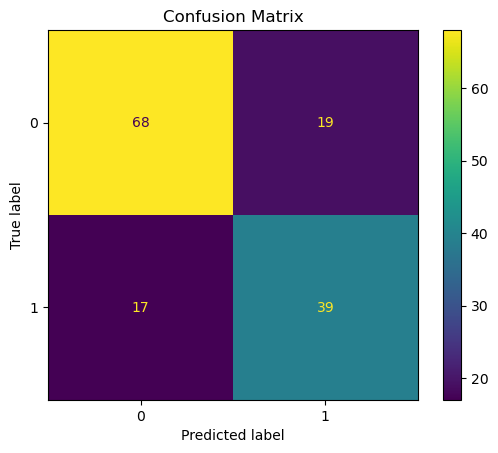

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

12. Evaluate using Precision, Recall, F1-Score

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.6724137931034483
Recall: 0.6964285714285714
F1 Score: 0.6842105263157895


13. Handling Imbalanced Data with Class Weights

In [29]:
imbalanced_model = LogisticRegression(class_weight='balanced', max_iter=1000)
imbalanced_model.fit(X_train, y_train)
print("Imbalanced Accuracy:", imbalanced_model.score(X_test, y_test))

Imbalanced Accuracy: 0.7272727272727273


14. Titanic Dataset with Missing Values

In [31]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df = df[['Pclass', 'Sex', 'Age', 'Survived']]
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

X = df[['Pclass', 'Sex', 'Age']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Titanic Accuracy:", model.score(X_test, y_test))

Titanic Accuracy: 0.8100558659217877


15. Feature Scaling (Standardization)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_s, y_train_s)

print("Accuracy with scaling:", model_scaled.score(X_test_s, y_test_s))
print("Accuracy without scaling:", model.score(X_test, y_test))  # Assuming `model` from earlier

Accuracy with scaling: 0.8044692737430168
Accuracy without scaling: 0.8100558659217877


16. Evaluate using ROC-AUC Score

In [35]:
from sklearn.metrics import roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

ROC-AUC Score: 0.8727799227799228


17. Custom Learning Rate (C = 0.5)

In [37]:
custom_model = LogisticRegression(C=0.5, max_iter=1000)
custom_model.fit(X_train, y_train)
print("Accuracy with C=0.5:", custom_model.score(X_test, y_test))

Accuracy with C=0.5: 0.8156424581005587


18. Feature Importance from Coefficients

In [39]:
import numpy as np

feature_names = X.columns if hasattr(X, 'columns') else [f'Feature {i}' for i in range(X.shape[1])]
importance = model.coef_[0]

for f, i in zip(feature_names, importance):
    print(f"{f}: {i:.4f}")

Pclass: -1.0355
Sex: -2.4742
Age: -0.0255


19. Evaluate using Cohen’s Kappa Score

In [47]:
from sklearn.metrics import cohen_kappa_score

print("Cohen’s Kappa Score:", cohen_kappa_score(y_test, y_pred))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

20. Precision-Recall Curve

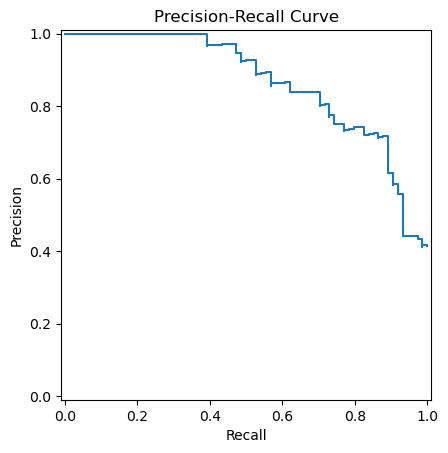

In [49]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

precision, recall, _ = precision_recall_curve(y_test, y_proba)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.title("Precision-Recall Curve")
plt.show()

 21. Compare Solvers

In [51]:
solvers = ['liblinear', 'lbfgs', 'saga']
for solver in solvers:
    try:
        model = LogisticRegression(solver=solver, max_iter=1000)
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        print(f"Solver: {solver}, Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"Solver: {solver} failed due to: {e}")

Solver: liblinear, Accuracy: 0.7877
Solver: lbfgs, Accuracy: 0.8101
Solver: saga, Accuracy: 0.7821


 22. Evaluate using Matthews Correlation Coefficient (MCC)

In [53]:
from sklearn.metrics import matthews_corrcoef

print("Matthews Correlation Coefficient:", matthews_corrcoef(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [179, 143]

23. Compare Raw vs Standardized Accuracy

In [55]:
raw_acc = model.score(X_test, y_test)
scaled_acc = model_scaled.score(X_test_s, y_test_s)

print("Raw Accuracy:", raw_acc)
print("Standardized Accuracy:", scaled_acc)

Raw Accuracy: 0.7821229050279329
Standardized Accuracy: 0.8044692737430168


24. Find Optimal C Using Cross-Validation

In [57]:
from sklearn.model_selection import cross_val_score

c_values = [0.01, 0.1, 1, 10, 100]
for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000)
    scores = cross_val_score(model, X, y, cv=5)
    print(f"C={c}, CV Accuracy: {scores.mean():.4f}")

C=0.01, CV Accuracy: 0.7554
C=0.1, CV Accuracy: 0.7789
C=1, CV Accuracy: 0.7868
C=10, CV Accuracy: 0.7868
C=100, CV Accuracy: 0.7868


25. Save and Load Model using joblib

In [59]:
import joblib

# Train and save model
final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train, y_train)
joblib.dump(final_model, 'logistic_model.pkl')

# Load and use model
loaded_model = joblib.load('logistic_model.pkl')
print("Loaded model accuracy:", loaded_model.score(X_test, y_test))

Loaded model accuracy: 0.8100558659217877
